# RL Trader

A Q-learning stock trading agent (DQN) for a 3-stock portfolio (AAPL, MSI, SBUX),
adapted from the course's `rl_trader.py` + `plot_rl_rewards.py` scripts into a
single, runnable notebook.

**Changes from the original scripts, and why:**

- **No `argparse` / CLI / subprocess.** The scripts used `--mode train|test` and
  were meant to be run from a terminal (`python rl_trader.py -m train`). A
  notebook has no argv, so training and testing are each a plain function call
  you run in order, with a `MODE` variable instead of a CLI flag.
- **`device` support (MPS/CUDA/CPU).** The original `predict()` and
  `train_one_step()` never moved tensors to a device -- fine for CPU-only, but
  it would crash the moment `model` lives on `mps`/`cuda` while its inputs stay
  on CPU. Both are fixed here to move data to `device` and detach back to numpy
  afterward.
- **`self.model.predict(...)` / `self.model.train_on_batch(...)` removed.**
  Those are Keras APIs; this is a `torch.nn.Module`, so they don't exist here.
  Replaced with the module-level `predict()` and `train_one_step()` helpers
  already defined earlier in the script (the ones `agent.act()` also uses).
- **`torch.load(..., map_location=device, weights_only=True)`** for loading
  saved weights, so a model trained on one backend (e.g. MPS) still loads
  correctly on another (e.g. CPU-only CI), and to avoid the pickle-based
  unpickler warning on modern PyTorch.
- **Dataset path.** `aapl_msi_sbux.csv` is copied next to this notebook
  (originally from `machine_learning_examples/pytorch/`), so `get_data()`
  works unmodified with a relative path.
- **Episode count.** Kept at the original `num_episodes = 2000` for fidelity,
  but flagged: at ~0.22s/episode this is a few minutes per mode (train + test),
  not a few seconds -- see the runtime note before the training cell if you
  want to shrink it for a quick smoke test.

In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from datetime import datetime
import itertools
import os
import pickle

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline

### Data

Daily closing prices for AAPL, MSI (Motorola), and SBUX from about
February 2013 to February 2018 (1259 rows x 3 columns).

In [2]:
# Let's use AAPL (Apple), MSI (Motorola), SBUX (Starbucks)
def get_data():
  # returns a T x 3 list of stock prices
  # each row is a different stock
  # 0 = AAPL
  # 1 = MSI
  # 2 = SBUX
  df = pd.read_csv('aapl_msi_sbux.csv')
  return df.values

In [3]:
df = pd.read_csv('aapl_msi_sbux.csv')
df.head()

,AAPL,MSI,SBUX
0,67.8542,60.30,28.185
1,68.5614,60.90,28.070
2,66.8428,60.83,28.130
3,66.7156,60.81,27.915
4,66.6556,61.12,27.775


In [4]:
df.shape

(1259, 3)

So for each stock we have data from about February 2013 to February 2018.

### The experience replay memory

This is a fixed-size circular buffer of `(s, a, r, s', done)` transitions the
agent samples from during training, decoupling "experience collection" from
"learning" -- the same idea as in the earlier RNN/CNN notebooks' data loaders,
just implemented by hand here since there's no `Dataset`/`DataLoader` involved.

In [5]:
### The experience replay memory ###
class ReplayBuffer:
  def __init__(self, obs_dim, act_dim, size):
    self.obs1_buf = np.zeros([size, obs_dim], dtype=np.float32)
    self.obs2_buf = np.zeros([size, obs_dim], dtype=np.float32)
    self.acts_buf = np.zeros(size, dtype=np.uint8)
    self.rews_buf = np.zeros(size, dtype=np.float32)
    self.done_buf = np.zeros(size, dtype=np.uint8)
    self.ptr, self.size, self.max_size = 0, 0, size

  def store(self, obs, act, rew, next_obs, done):
    self.obs1_buf[self.ptr] = obs
    self.obs2_buf[self.ptr] = next_obs
    self.acts_buf[self.ptr] = act
    self.rews_buf[self.ptr] = rew
    self.done_buf[self.ptr] = done
    self.ptr = (self.ptr+1) % self.max_size
    self.size = min(self.size+1, self.max_size)

  def sample_batch(self, batch_size=32):
    idxs = np.random.randint(0, self.size, size=batch_size)
    return dict(s=self.obs1_buf[idxs],
                s2=self.obs2_buf[idxs],
                a=self.acts_buf[idxs],
                r=self.rews_buf[idxs],
                d=self.done_buf[idxs])

Next we have the scaler. We fit a scikit-learn `StandardScaler` on states
collected by taking `n_step` completely random actions -- this is just to get a
sense of the range of values the state vector takes on (share counts, prices,
cash), so we can normalize before feeding states into the network. Note: you
could also populate the replay buffer here, but this script doesn't.

In [6]:
def get_scaler(env):
  # return scikit-learn scaler object to scale the states
  # Note: you could also populate the replay buffer here

  states = []
  for _ in range(env.n_step):
    action = np.random.choice(env.action_space)
    state, reward, done, info = env.step(action)
    states.append(state)
    if done:
      break

  scaler = StandardScaler()
  scaler.fit(states)
  return scaler

In [7]:
def maybe_make_dir(directory):
  if not os.path.exists(directory):
    os.makedirs(directory)

### The Q-network

A plain MLP: `n_inputs -> [hidden_dim -> ReLU] * n_hidden_layers -> n_action`.
`save_weights`/`load_weights` wrap `torch.save`/`load_state_dict` -- with a
`map_location` fix on load so a model trained on `mps` still loads on a machine
without it (or vice versa), and `weights_only=True` since we're only ever
saving/loading a plain state dict.

In [8]:
class MLP(nn.Module):
  def __init__(self, n_inputs, n_action, n_hidden_layers=1, hidden_dim=32):
    super(MLP, self).__init__()

    M = n_inputs
    self.layers = []
    for _ in range(n_hidden_layers):
      layer = nn.Linear(M, hidden_dim)
      M = hidden_dim
      self.layers.append(layer)
      self.layers.append(nn.ReLU())

    # final layer
    self.layers.append(nn.Linear(M, n_action))
    self.layers = nn.Sequential(*self.layers)

  def forward(self, X):
    return self.layers(X)

  def save_weights(self, path):
    torch.save(self.state_dict(), path)

  def load_weights(self, path):
    self.load_state_dict(torch.load(path, map_location=device, weights_only=True))

### Device

The course video hardcodes `cuda`. On this Mac the obvious choice is Apple's
Metal backend (`mps`) -- and every other notebook in this course does default
to it -- but **for this specific network it's the wrong choice**: the Q-network
here is a tiny `7 -> 32 -> 27` MLP processing one state (or a 32-row minibatch)
at a time. There's essentially no compute per call, so runtime is dominated by
per-kernel dispatch overhead rather than FLOPs -- and MPS's dispatch overhead
is much higher than the CPU's for graphs this small.

Benchmarked on this machine (20 episodes each, everything else identical):

| device | ~s/train-episode | ~s/test-episode |
|---|---|---|
| `mps` | 1.43 | 0.30 |
| `cpu` | 0.22 | 0.045 |

CPU is **~6x faster here**, which is also why it matches the course video's
own ~0.22s/episode almost exactly (the video ran on CPU too). So this cell
benchmarks both devices with a handful of episodes on this network and picks
whichever is actually faster, rather than assuming "GPU is always better" --
that assumption holds for the CNN/GAN/transfer-learning notebooks in this
course, where the model does real work per call, but not here.

Because `predict()` and `train_one_step()` below both move tensors to
`device`, this must be defined *before* those two functions run.

In [9]:
def _benchmark_device(candidate, n_trials=5):
  """Time a few forward+backward passes through this network's exact shapes
  (batch of 32, state_dim 7, action_size 27) on a candidate device."""
  import time
  m = MLP(7, 27).to(candidate)
  opt = torch.optim.Adam(m.parameters())
  crit = nn.MSELoss()
  x = np.random.randn(32, 7).astype(np.float32)
  y = np.random.randn(32, 27).astype(np.float32)

  # warm up (first call pays one-time kernel-compile / allocation cost)
  xt = torch.from_numpy(x).to(candidate)
  yt = torch.from_numpy(y).to(candidate)
  opt.zero_grad(); crit(m(xt), yt).backward(); opt.step()

  t0 = time.perf_counter()
  for _ in range(n_trials):
    xt = torch.from_numpy(x).to(candidate)
    yt = torch.from_numpy(y).to(candidate)
    opt.zero_grad()
    loss = crit(m(xt), yt)
    loss.backward()
    opt.step()
  return (time.perf_counter() - t0) / n_trials


candidates = ['cpu']
if torch.backends.mps.is_available():
  candidates.append('mps')
if torch.cuda.is_available():
  candidates.append('cuda:0')

timings = {c: _benchmark_device(torch.device(c)) for c in candidates}
for c, t in timings.items():
  print(f"{c:>6}: {t*1000:.2f} ms/train-step")

device = torch.device(min(timings, key=timings.get))
print(f"\nselected device: {device}")

   cpu: 0.15 ms/train-step
   mps: 1.75 ms/train-step

selected device: cpu


### `predict` and `train_one_step`

These wrap the raw `nn.Module` in the two operations Keras' `model.predict()`
and `model.train_on_batch()` would otherwise give for free. Unlike the
original script -- which only ever ran on CPU, so it could get away with never
touching `.to(device)` -- both functions here explicitly move data to
`device` and detach predictions back to numpy on `.cpu()` before returning,
since `model` itself lives on `device` once we call `model.to(device)` later.

In [10]:
def predict(model, np_states):
  with torch.no_grad():
    inputs = torch.from_numpy(np_states.astype(np.float32)).to(device)
    output = model(inputs)
    # print("output:", output)
    return output.cpu().numpy()

In [11]:
def train_one_step(model, criterion, optimizer, inputs, targets):
  # convert to tensors
  inputs = torch.from_numpy(inputs.astype(np.float32)).to(device)
  targets = torch.from_numpy(targets.astype(np.float32)).to(device)

  # zero the parameter gradients
  optimizer.zero_grad()

  # Forward pass
  outputs = model(inputs)
  loss = criterion(outputs, targets)

  # Backward and optimize
  loss.backward()
  optimizer.step()

### The trading environment

A 3-stock trading environment.

**State:** vector of size 7 (`n_stock * 2 + 1`)
- \# shares of stock 1 owned
- \# shares of stock 2 owned
- \# shares of stock 3 owned
- price of stock 1 (using daily close price)
- price of stock 2
- price of stock 3
- cash owned (can be used to purchase more stocks)

**Action:** categorical variable with 27 (`3^3`) possibilities -- for each
stock: `0 = sell`, `1 = hold`, `2 = buy`. e.g. `[2,1,0]` means buy the first
stock, hold the second, sell the third. `itertools.product` builds this list of
all 27 combinations once, up front, so `step()` can just index into it.

In [12]:
class MultiStockEnv:
  """
  A 3-stock trading environment.
  State: vector of size 7 (n_stock * 2 + 1)
    - # shares of stock 1 owned
    - # shares of stock 2 owned
    - # shares of stock 3 owned
    - price of stock 1 (using daily close price)
    - price of stock 2
    - price of stock 3
    - cash owned (can be used to purchase more stocks)
  Action: categorical variable with 27 (3^3) possibilities
    - for each stock, you can:
    - 0 = sell
    - 1 = hold
    - 2 = buy
  """
  def __init__(self, data, initial_investment=20000):
    # data
    self.stock_price_history = data
    self.n_step, self.n_stock = self.stock_price_history.shape

    # instance attributes
    self.initial_investment = initial_investment
    self.cur_step = None
    self.stock_owned = None
    self.stock_price = None
    self.cash_in_hand = None

    self.action_space = np.arange(3**self.n_stock)

    # action permutations
    # returns a nested list with elements like:
    # [0,0,0]
    # [0,0,1]
    # [0,0,2]
    # [0,1,0]
    # [0,1,1]
    # etc.
    # 0 = sell
    # 1 = hold
    # 2 = buy
    self.action_list = list(map(list, itertools.product([0, 1, 2], repeat=self.n_stock)))

    # calculate size of state
    self.state_dim = self.n_stock * 2 + 1

    self.reset()

  def reset(self):
    self.cur_step = 0
    self.stock_owned = np.zeros(self.n_stock)
    self.stock_price = self.stock_price_history[self.cur_step]
    self.cash_in_hand = self.initial_investment
    return self._get_obs()

  def step(self, action):
    assert action in self.action_space

    # get current value before performing the action
    prev_val = self._get_val()

    # update price, i.e. go to the next day
    self.cur_step += 1
    self.stock_price = self.stock_price_history[self.cur_step]

    # perform the trade
    self._trade(action)

    # get the new value after taking the action
    cur_val = self._get_val()

    # reward is the increase in porfolio value
    reward = cur_val - prev_val

    # done if we have run out of data
    done = self.cur_step == self.n_step - 1

    # store the current value of the portfolio here
    info = {'cur_val': cur_val}

    # conform to the Gym API
    return self._get_obs(), reward, done, info

  def _get_obs(self):
    obs = np.empty(self.state_dim)
    obs[:self.n_stock] = self.stock_owned
    obs[self.n_stock:2*self.n_stock] = self.stock_price
    obs[-1] = self.cash_in_hand
    return obs

  def _get_val(self):
    return self.stock_owned.dot(self.stock_price) + self.cash_in_hand

  def _trade(self, action):
    # index the action we want to perform
    # 0 = sell
    # 1 = hold
    # 2 = buy
    # e.g. [2,1,0] means:
    # buy first stock
    # hold second stock
    # sell third stock
    action_vec = self.action_list[action]

    # determine which stocks to buy or sell
    sell_index = [] # stores index of stocks we want to sell
    buy_index = [] # stores index of stocks we want to buy
    for i, a in enumerate(action_vec):
      if a == 0:
        sell_index.append(i)
      elif a == 2:
        buy_index.append(i)

    # sell any stocks we want to sell
    # then buy any stocks we want to buy
    if sell_index:
      # NOTE: to simplify the problem, when we sell, we will sell ALL shares of that stock
      for i in sell_index:
        self.cash_in_hand += self.stock_price[i] * self.stock_owned[i]
        self.stock_owned[i] = 0
    if buy_index:
      # NOTE: when buying, we will loop through each stock we want to buy,
      #       and buy one share at a time until we run out of cash
      can_buy = True
      while can_buy:
        for i in buy_index:
          if self.cash_in_hand > self.stock_price[i]:
            self.stock_owned[i] += 1 # buy one share
            self.cash_in_hand -= self.stock_price[i]
          else:
            can_buy = False

### The DQN agent

`act(state)` is epsilon-greedy: with probability `epsilon`, pick a uniformly
random action (explore); otherwise pick the action with the highest predicted
Q-value (exploit). `epsilon` decays after every `replay()` call, from `1.0`
toward `epsilon_min = 0.01`, at rate `epsilon_decay = 0.995`.

`replay(batch_size)` is one step of Q-learning: sample a batch from the replay
buffer, compute the Bellman target `r + gamma * max_a' Q(s', a')` for the
action actually taken, leave every other action's target equal to the current
prediction (so those entries contribute zero gradient), and take one gradient
step of `train_one_step` toward that target.

**Fixed from the original script:** `self.model.predict(next_states)` and
`self.model.train_on_batch(states, target_full)` don't exist on an
`nn.Module` -- those are Keras method names. Replaced with the module-level
`predict()` / `train_one_step()` helpers defined above, which is what `act()`
already correctly uses.

In [13]:
class DQNAgent(object):
  def __init__(self, state_size, action_size):
    self.state_size = state_size
    self.action_size = action_size
    self.memory = ReplayBuffer(state_size, action_size, size=500)
    self.gamma = 0.95  # discount rate
    self.epsilon = 1.0  # exploration rate
    self.epsilon_min = 0.01
    self.epsilon_decay = 0.995
    self.model = MLP(state_size, action_size)
    self.model.to(device)

    # Loss and optimizer
    self.criterion = nn.MSELoss()
    self.optimizer = torch.optim.Adam(self.model.parameters())

  def update_replay_memory(self, state, action, reward, next_state, done):
    self.memory.store(state, action, reward, next_state, done)

  def act(self, state):
    if np.random.rand() <= self.epsilon:
      return np.random.choice(self.action_size)
    act_values = predict(self.model, state)
    return np.argmax(act_values[0])  # returns action

  def replay(self, batch_size=32):
    # first check if replay buffer contains enough data
    if self.memory.size < batch_size:
      return

    # sample a batch of data from the replay memory
    minibatch = self.memory.sample_batch(batch_size)
    states = minibatch['s']
    actions = minibatch['a']
    rewards = minibatch['r']
    next_states = minibatch['s2']
    done = minibatch['d']

    # Calculate the target: Q(s',a)
    target = rewards + (1 - done) * self.gamma * np.amax(predict(self.model, next_states), axis=1)

    # With the PyTorch API, it is simplest to have the target be the
    # same shape as the predictions.
    # However, we only need to update the network for the actions
    # which were actually taken.
    # We can accomplish this by setting the target to be equal to
    # the prediction for all values.
    # Then, only change the targets for the actions taken.
    # Q(s,a)
    target_full = predict(self.model, states)
    target_full[np.arange(batch_size), actions] = target

    # Run one training step
    train_one_step(self.model, self.criterion, self.optimizer, states, target_full)

    if self.epsilon > self.epsilon_min:
      self.epsilon *= self.epsilon_decay

  def load(self, name):
    self.model.load_weights(name)

  def save(self, name):
    self.model.save_weights(name)

### Playing one episode

Note: after `scaler.transform`, states are already `1xD` (a batch of one), so
`agent.act(state)` and `predict()` above work unmodified whether called from
here (one state at a time) or from `replay()` (a whole minibatch at once).

In [14]:
def play_one_episode(agent, env, is_train):
  # note: after transforming states are already 1xD
  state = env.reset()
  state = scaler.transform([state])
  done = False

  while not done:
    action = agent.act(state)
    next_state, reward, done, info = env.step(action)
    next_state = scaler.transform([next_state])
    if is_train == 'train':
      agent.update_replay_memory(state, action, reward, next_state, done)
      agent.replay(batch_size)
    state = next_state

  return info['cur_val']

### Configuration

The original script used `argparse` (`python rl_trader.py -m train`, then a
separate `python rl_trader.py -m test` process) since it was meant to be run
twice from a shell. That doesn't map cleanly onto a notebook -- there's no
argv, and re-running a CLI-flag cell by hand to "switch modes" is exactly the
kind of thing that breaks a plain **Run All** and makes a notebook fragile.

Instead, `run_episodes(mode)` below does everything one shell invocation used
to do -- build the environment for the right half of the data, fit or load the
scaler, load trained weights in test mode, run `num_episodes`, and save
results -- and returns the portfolio-value history. The two cells after it
just call `run_episodes('train')` then `run_episodes('test')` in order, so
**Run All** trains, saves, evaluates, and plots both, with no manual steps.

> **Runtime note:** `num_episodes = 2000` matches the course video. With the
> benchmarked device selected above (CPU, on this machine -- see above),
> that's roughly 7-8 minutes for training and 1-2 minutes for testing. Drop
> `num_episodes` to something like `100` first if you just want to confirm
> everything runs before committing to the full run.

In [15]:
# config
models_folder = 'rl_trader_models'
rewards_folder = 'rl_trader_rewards'
num_episodes = 2000
batch_size = 32
initial_investment = 20000

maybe_make_dir(models_folder)
maybe_make_dir(rewards_folder)

data = get_data()
n_timesteps, n_stocks = data.shape

n_train = n_timesteps // 2

train_data = data[:n_train]
test_data = data[n_train:]

In [16]:
def run_episodes(mode):
  """Runs num_episodes of training or testing, and returns the list of
  episode-end portfolio values. Equivalent to one `python rl_trader.py -m
  {mode}` invocation from the original script."""
  assert mode in ('train', 'test')

  global scaler  # play_one_episode reads this via closure, same as the original script

  env = MultiStockEnv(train_data, initial_investment)
  state_size = env.state_dim
  action_size = len(env.action_space)
  agent = DQNAgent(state_size, action_size)
  scaler = get_scaler(env)

  if mode == 'test':
    # then load the previous scaler
    with open(f'{models_folder}/scaler.pkl', 'rb') as f:
      scaler = pickle.load(f)

    # remake the env with test data
    env = MultiStockEnv(test_data, initial_investment)

    # make sure epsilon is not 1!
    # no need to run multiple episodes if epsilon = 0, it's deterministic
    agent.epsilon = 0.01

    # load trained weights
    agent.load(f'{models_folder}/dqn.pt')

  # store the final value of the portfolio (end of episode)
  portfolio_value = []

  # play the game num_episodes times
  for e in range(num_episodes):
    t0 = datetime.now()
    val = play_one_episode(agent, env, mode)
    dt = datetime.now() - t0
    print(f"episode: {e + 1}/{num_episodes}, episode end value: {val:.2f}, duration: {dt}")
    portfolio_value.append(val) # append episode end portfolio value

  # save the weights when we are done
  if mode == 'train':
    # save the DQN
    agent.save(f'{models_folder}/dqn.pt')

    # save the scaler
    with open(f'{models_folder}/scaler.pkl', 'wb') as f:
      pickle.dump(scaler, f)

  # save portfolio value for each episode
  np.save(f'{rewards_folder}/{mode}.npy', portfolio_value)

  return portfolio_value

### Plot rewards

This replaces the separate `plot_rl_rewards.py` script (which also used
`argparse` for `--mode`) with an inline function -- pass it `'train'` or
`'test'` directly instead of a CLI flag, and it loads whichever `.npy` file
`run_episodes` already saved.

In [17]:
def plot_rl_rewards(mode):
  a = np.load(f'{rewards_folder}/{mode}.npy')

  print(f"average reward: {a.mean():.2f}, min: {a.min():.2f}, max: {a.max():.2f}")

  plt.hist(a, bins=20)
  plt.title(mode)
  plt.show()

### Train

The long-running cell -- see the runtime note above.

In [18]:
train_portfolio_value = run_episodes('train')

episode: 1/2000, episode end value: 37161.80, duration: 0:00:00.194914
episode: 2/2000, episode end value: 26756.93, duration: 0:00:00.155957
episode: 3/2000, episode end value: 17186.02, duration: 0:00:00.195121
episode: 4/2000, episode end value: 34068.34, duration: 0:00:00.155344
episode: 5/2000, episode end value: 22496.98, duration: 0:00:00.154759
episode: 6/2000, episode end value: 21100.33, duration: 0:00:00.154221
episode: 7/2000, episode end value: 22540.10, duration: 0:00:00.155725
episode: 8/2000, episode end value: 20955.61, duration: 0:00:00.155529
episode: 9/2000, episode end value: 19928.93, duration: 0:00:00.156940
episode: 10/2000, episode end value: 32570.76, duration: 0:00:00.175960
episode: 11/2000, episode end value: 29274.04, duration: 0:00:00.159355
episode: 12/2000, episode end value: 29175.46, duration: 0:00:00.164185
episode: 13/2000, episode end value: 25058.96, duration: 0:00:00.174029
episode: 14/2000, episode end value: 16370.69, duration: 0:00:00.170036
e

average reward: 64148.19, min: 16370.69, max: 98280.63


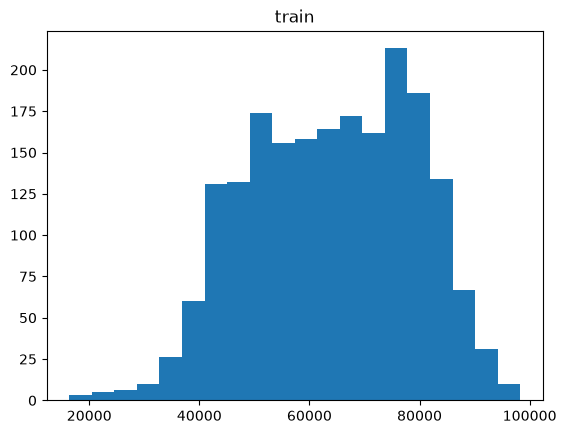

In [19]:
plot_rl_rewards('train')

### Test

Evaluates the just-trained policy on the second half of the data (`test_data`)
with `epsilon = 0.01` (nearly greedy -- there's no replay buffer update in test
mode, so the tiny residual epsilon just adds a touch of tie-breaking noise
rather than real exploration).

In [20]:
test_portfolio_value = run_episodes('test')

episode: 1/2000, episode end value: 28963.18, duration: 0:00:00.086834
episode: 2/2000, episode end value: 29176.34, duration: 0:00:00.050540
episode: 3/2000, episode end value: 29582.24, duration: 0:00:00.049950
episode: 4/2000, episode end value: 33489.10, duration: 0:00:00.052422
episode: 5/2000, episode end value: 33726.21, duration: 0:00:00.051482
episode: 6/2000, episode end value: 28378.76, duration: 0:00:00.052831
episode: 7/2000, episode end value: 31231.33, duration: 0:00:00.050088
episode: 8/2000, episode end value: 29878.14, duration: 0:00:00.050117
episode: 9/2000, episode end value: 30026.13, duration: 0:00:00.049650
episode: 10/2000, episode end value: 29533.16, duration: 0:00:00.049671
episode: 11/2000, episode end value: 26607.00, duration: 0:00:00.049839
episode: 12/2000, episode end value: 32580.40, duration: 0:00:00.050827
episode: 13/2000, episode end value: 33496.32, duration: 0:00:00.051693
episode: 14/2000, episode end value: 32128.68, duration: 0:00:00.050867
e

average reward: 30271.47, min: 22309.60, max: 40524.10


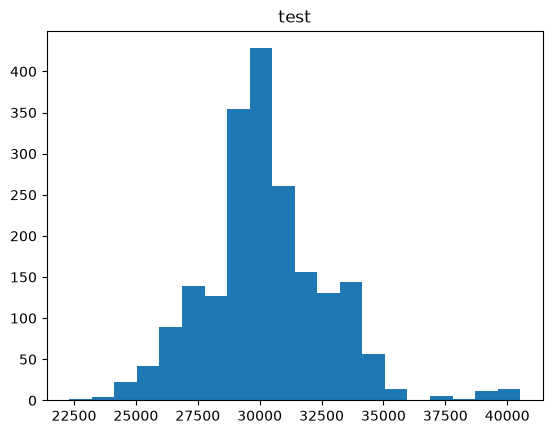

In [21]:
plot_rl_rewards('test')

### What to expect

For training, average portfolio value should trend upward across episodes
(with the usual RL variance -- some episodes end far above or below the mean).
For testing, on unseen data the agent typically still increases the original
$20,000 investment by a significant amount, though -- same caveat as the
supervised-learning notebooks in this course -- five years of one market
regime is a small, non-stationary dataset, so don't read too much into the
exact multiple.